# Layer Normalization for LSTM Training Stability

This notebook extends our from-scratch LSTM by adding **Layer Normalization** (LayerNorm) — a technique that stabilizes training by normalizing gate pre-activations inside the LSTM cell.

We will:
1. Understand **why** normalization stabilizes training (internal covariate shift)
2. Contrast LayerNorm vs BatchNorm — and why LayerNorm is the right choice for RNNs
3. Implement LayerNorm **from scratch**, then verify against `nn.LayerNorm`
4. Wire LayerNorm into our LSTMCell and train a character-level language model
5. Compare training dynamics: vanilla LSTM vs LayerNorm-LSTM (side by side)

## 1. Motivation: Why Normalize Gate Activations?

Our from-scratch LSTM works — it learns to generate plausible names and matches PyTorch's `nn.LSTM`. But training can be **sensitive to the learning rate and weight initialization**. The reason lies in how gate activations behave during early training.

Recall that each gate computes a linear projection followed by a nonlinearity:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

The problem: if the pre-activation values fed into $\sigma$ have very different magnitudes across features, some neurons saturate (output near 0 or 1) while others barely activate. Saturated sigmoids have near-zero gradients, so those weights barely update — leading to **uneven learning** across the hidden dimension. This gets worse over time as the distributions of $h_{t-1}$ shift during training, a phenomenon loosely called **internal covariate shift**.

**Layer Normalization** (Ba et al., 2016) fixes this by normalizing the pre-activation vector to zero mean and unit variance **before** applying the nonlinearity. This ensures every feature enters the sigmoid/tanh on equal footing, regardless of the current scale of activations.

The practical payoff: stabilized gate activations mean you can use **higher learning rates** without divergence, training converges **faster**, and the network is **less sensitive to initialization**.

LayerNorm is also directly transferable knowledge — it's a core component of **every Transformer block**, where it normalizes the residual stream before each attention and MLP sub-layer.

## 2. LayerNorm vs BatchNorm: Why LayerNorm for RNNs?

Both normalize activations to zero mean / unit variance before scaling+shifting with learnable parameters, but **what they normalize across differs**:

- **BatchNorm** normalizes each feature across the **batch** dimension — it needs many examples at once to compute meaningful statistics, and its behavior differs between training (batch stats) and eval (running stats).
- **LayerNorm** normalizes each example across its own **feature** dimension — no dependency on batch size or other examples in the batch.

This matters for RNNs specifically: batches contain sequences of **different lengths** (handled via padding, as in Part 1's masking logic), and hidden states differ across timesteps. Computing a clean "batch statistic" per timestep is awkward once padding is involved. LayerNorm sidesteps this entirely — it only ever looks at one example's own features, so padding position doesn't affect its statistics.

**Where it plugs in:** applied to each gate's **pre-activation** — the linear output *before* `sigmoid`/`tanh`, not the raw concatenated input and not the post-activation gate value.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [15]:
# Data preparation — same as Part 1

with open('assets/names.txt', 'r', encoding='utf-8') as f:
    words = f.read().splitlines()
print(f'Number of names: {len(words)}')

# Build vocabulary
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
itos = {i+1: s for i, s in enumerate(chars)}
itos[0] = '.'
vocab_size = len(stoi) + 1
PAD_IDX = vocab_size
itos[PAD_IDX] = '<pad>'
vocab_size += 1

def encode(name):
    return [0] + [stoi[c] for c in name] + [0]

# Decode: list of indices → string
def decode(indices):
    """Decode a list of character indices back to a string."""
    return ''.join(itos[i] for i in indices)

print(f'Vocabulary size: {vocab_size} (including PAD_IDX={PAD_IDX})')
print(f'First 8 names: {words[:8]}')

# First, define the vanilla LSTMCell from Part 1 (needed for comparison)
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        combined_size = input_size + hidden_size
        self.W_f = nn.Linear(combined_size, hidden_size)
        self.W_i = nn.Linear(combined_size, hidden_size)
        self.W_g = nn.Linear(combined_size, hidden_size)
        self.W_o = nn.Linear(combined_size, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, x, state=None):
        if state is None:
            zeros = torch.zeros(x.size(0), self.hidden_size, dtype=x.dtype, device=x.device)
            state = (zeros, zeros)
        h_prev, c_prev = state
        x_h_combined = torch.cat([x, h_prev], dim=-1)
        
        f_t = torch.sigmoid(self.W_f(x_h_combined))
        i_t = torch.sigmoid(self.W_i(x_h_combined))
        g_t = torch.tanh(self.W_g(x_h_combined))
        o_t = torch.sigmoid(self.W_o(x_h_combined))
        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

Number of names: 108
Vocabulary size: 28 (including PAD_IDX=27)
First 8 names: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


## 3. LayerNorm from Scratch

We'll implement LayerNorm as a standalone `nn.Module` before wiring it into the LSTM. The implementation is surprisingly small — the subtlety is getting the **normalized dimension** right.

$$\text{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta$$

- $\mu$ and $\sigma^2$ are computed over the **last dimension** (features)
- $\gamma$ (scale) is initialized to **ones** — at init, the normalization is a no-op
- $\beta$ (shift) is initialized to **zeros** — same reason
- $\epsilon = 10^{-5}$ prevents division by zero

In [16]:
class LayerNorm(nn.Module):

    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(normalized_shape))  # gamma: init to ones — doesn't change the output at init
        self.beta = nn.Parameter(torch.zeros(normalized_shape))  # beta: init to zeros — doesn't change the output at init
        self.eps = eps
        
    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_norm = (x - mean) / torch.sqrt(var + self.eps)   # normalize
        return self.gamma * x_norm + self.beta             # scale and shift

In [17]:
# Verify our LayerNorm against PyTorch's nn.LayerNorm

hidden_size = 64

ln_ours = LayerNorm(hidden_size)
ln_pytorch = nn.LayerNorm(hidden_size)

# Sync parameters so both produce identical output
with torch.no_grad():
    ln_pytorch.weight.copy_(ln_ours.gamma)
    ln_pytorch.bias.copy_(ln_ours.beta)

# Test with random input (batch of 4, hidden_size)
x_test = torch.randn(4, hidden_size)
print(f'x_test.shape: {x_test.shape}')
print(f'x_test[0].mean(-1): {x_test[0].mean(dim=-1,).item():.6f}')

out_ours = ln_ours(x_test)
out_pytorch = ln_pytorch(x_test)
print(f'out_ours[3].mean(dim=-1,): {out_ours[3, :].mean(dim=-1, keepdim=True).item():.6f}')

# Compare
max_diff = (out_ours - out_pytorch).abs().max().item()
print(f'Max absolute difference: {max_diff:.2e}')
print(f'Match: {"YES" if max_diff < 1e-6 else "NO"}  (tolerance: 1e-6)')

# Verify the normalization properties
print(f'\nAfter our LayerNorm (gamma=1, beta=0 at init):')
print(f'  Mean per example: {out_ours[0, :].mean().item():.6f} (should be ~0)')
print(f'  Std per example:  {out_ours[0, :].std(unbiased=False).item():.6f} (should be ~1)')

print(f'\nParameter counts:')
print(f'  Our LayerNorm: {sum(p.numel() for p in ln_ours.parameters())} params')
print(f'  nn.LayerNorm:  {sum(p.numel() for p in ln_pytorch.parameters())} params')

x_test.shape: torch.Size([4, 64])
x_test[0].mean(-1): -0.040288
out_ours[3].mean(dim=-1,): 0.000000
Max absolute difference: 2.38e-07
Match: YES  (tolerance: 1e-6)

After our LayerNorm (gamma=1, beta=0 at init):
  Mean per example: 0.000000 (should be ~0)
  Std per example:  0.999993 (should be ~1)

Parameter counts:
  Our LayerNorm: 128 params
  nn.LayerNorm:  128 params


## 4. LSTMCell with LayerNorm

Now we add LayerNorm into our LSTM cell. The key design choice: **where** to apply it?

**Standard approach** (Ba et al., 2016): normalize the **gate pre-activations** *before* the sigmoid/tanh nonlinearity. Each gate gets its own LayerNorm with separate $\gamma, \beta$ parameters, since forget/input/output gates serve different purposes.

$$\hat{a}_f = \text{LayerNorm}(W_f \cdot [h_{t-1}, x_t] + b_f)$$
$$f_t = \sigma(\hat{a}_f)$$

The cell state update and hidden state computation remain **unchanged** — normalization is only applied to the gate inputs.

We'll also experiment with normalizing $C_t$ later in Section 9.

In [18]:
class LSTMCell_LN(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()
        combined_size = input_size + hidden_size
        self.hidden_size = hidden_size
        
        # Gate projections (same as vanilla LSTMCell)
        self.W_f = nn.Linear(combined_size, hidden_size)
        self.W_i = nn.Linear(combined_size, hidden_size)
        self.W_g = nn.Linear(combined_size, hidden_size)
        self.W_o = nn.Linear(combined_size, hidden_size)

        # LayerNorm for each gate — normalize before the nonlinearity
        self.ln_f = LayerNorm(hidden_size)
        self.ln_i = LayerNorm(hidden_size)
        self.ln_g = LayerNorm(hidden_size)
        self.ln_o = LayerNorm(hidden_size)
        
    def forward(self, x, state=None):
        if state is None:
            zeros = torch.zeros(x.size(0), self.hidden_size, dtype=x.dtype, device=x.device)
            state = (zeros, zeros)

        h_prev, c_prev = state
        x_h_combined = torch.cat([x, h_prev], dim=-1)

        # compute pre-activations, then layerNormalize and finally apply non-linearity(sigmoid or tanh) for all gates
        f_t = torch.sigmoid(self.ln_f(self.W_f(x_h_combined))) # activation(layerNorm(pre-activation))
        i_t = torch.sigmoid(self.ln_i(self.W_i(x_h_combined)))
        g_t = torch.tanh(self.ln_g(self.W_g(x_h_combined)))
        o_t = torch.sigmoid(self.ln_o(self.W_o(x_h_combined)))
        c_t = f_t * c_prev + i_t * g_t
        h_t = o_t * torch.tanh(c_t)
        return h_t, c_t

In [27]:
# Trace "emma" through both cells side by side (identical gate weights)
vocab_size = 28
emb_size = 24
hidden_size = 64

# Create both cells with the same seed
torch.manual_seed(42)
lstm_vanilla = LSTMCell(vocab_size, hidden_size)

torch.manual_seed(42)
lstm_ln = LSTMCell_LN(vocab_size, hidden_size)

# Copy the gate weights (LN params are separate, no copy needed)
with torch.no_grad():
    lstm_ln.W_f.weight.copy_(lstm_vanilla.W_f.weight)
    lstm_ln.W_f.bias.copy_(lstm_vanilla.W_f.bias)
    lstm_ln.W_i.weight.copy_(lstm_vanilla.W_i.weight)
    lstm_ln.W_i.bias.copy_(lstm_vanilla.W_i.bias)
    lstm_ln.W_g.weight.copy_(lstm_vanilla.W_g.weight)
    lstm_ln.W_g.bias.copy_(lstm_vanilla.W_g.bias)
    lstm_ln.W_o.weight.copy_(lstm_vanilla.W_o.weight)
    lstm_ln.W_o.bias.copy_(lstm_vanilla.W_o.bias)

encoded_name = encode('emma')  # proper encoding after data prep

print(f'Tracing "emma" through both cells (identical gate weights):')
print('=' * 70)
print(f'{"char":>6} | {"Vanilla |h|":>12} {"Vanilla |C|":>12} | {"LN |h|":>12} {"LN |C|":>12}')
print('-' * 70)

state_vanilla = None
state_ln = None

for idx in encoded_name:
    x_t = F.one_hot(torch.tensor([idx]), vocab_size).float()
    state_vanilla = lstm_vanilla(x_t, state_vanilla)
    state_ln = lstm_ln(x_t, state_ln)
    char = itos[idx]
    print(f'{char:>6} | {state_vanilla[0].norm().item():>12.4f} {state_vanilla[1].norm().item():>12.4f} | {state_ln[0].norm().item():>12.4f} {state_ln[1].norm().item():>12.4f}')

print(f'\nWith identical gate weights, LayerNorm changes the output magnitudes')
print(f'because it normalizes pre-activations before sigmoid/tanh.')

Tracing "emma" through both cells (identical gate weights):
  char |  Vanilla |h|  Vanilla |C| |       LN |h|       LN |C|
----------------------------------------------------------------------
     . |       0.1719       0.3409 |       1.3442       2.7812
     e |       0.2425       0.4797 |       1.6452       3.3392
     m |       0.2623       0.5259 |       1.7845       4.0537
     m |       0.2978       0.5984 |       2.0779       4.6507
     a |       0.2956       0.5920 |       2.0542       4.6541
     . |       0.2958       0.5914 |       2.0034       4.7236

With identical gate weights, LayerNorm changes the output magnitudes
because it normalizes pre-activations before sigmoid/tanh.


## 5. The Full Model: `CharLSTM`

`CharLSTM` below takes the `cell_class` as a constructor argument, so no separate LN-specific wrapper is needed — just instantiate it with `LSTMCell_LN` instead of `LSTMCell`.

```
Character (int) -> Embedding -> LayerNorm-LSTM (unrolled) -> Linear -> logits -> CrossEntropy
```

In [29]:
class CharLSTM(nn.Module):
    def __init__(self, input_size, emb_size, hidden_size, cell_class=LSTMCell, pad_idx=None):
        super().__init__()
        self.emb = nn.Embedding(input_size, emb_size, padding_idx=pad_idx)
        self.lstm_cell = cell_class(emb_size, hidden_size)
        self.fc = nn.Linear(hidden_size, input_size)
        self.hidden_size = hidden_size

    def forward(self, x, state=None):
        """
        Args:
            x: tensor of batch of character indices, shape (batch, seq_len)
        Returns:
            logits: shape (batch, seq_len, vocab_size)
        """
        embs = self.emb(x)  # (B, T, emb_size)
        B, T, C = embs.shape

        if state is None:
            zeros = torch.zeros(B, self.hidden_size, dtype=embs.dtype, device=x.device)
            state = (zeros, zeros)
        h, c = state

        logits_list = []
        for t in range(T):
            h, c = self.lstm_cell(embs[:, t, :], (h, c))
            logits_list.append(self.fc(h))
        return torch.stack(logits_list, dim=1)  # (B, T, vocab_size)

## 6. Training: Vanilla LSTM vs LayerNorm-LSTM

The experiment: train both models with **identical** hyperparameters (learning rate, batch size, epochs, seed). What we expect:
- LayerNorm converges **faster** (lower loss at each epoch)
- LayerNorm is **more stable** — less likely to diverge at higher learning rates

We'll also do a second experiment: cranking up the learning rate to show the vanilla model struggling while LayerNorm handles it gracefully.

In [30]:
import time
import random
from torch.nn.utils.rnn import pad_sequence

def train_model(model, words, num_epochs=100, batch_size=32, lr=0.01):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lossi, stepi = [], []
    total_steps = 0
    t0 = time.time()

    for epoch in range(num_epochs):
        random.shuffle(words)
        epoch_loss, num_batches = 0.0, 0

        for batch_start in range(0, len(words), batch_size):
            batch_words = words[batch_start:batch_start + batch_size]
            encoded_names = [torch.tensor(encode(name)) for name in batch_words]
            idx_batch_seq = pad_sequence(encoded_names, batch_first=True, padding_value=PAD_IDX)

            inputs = idx_batch_seq[:, :-1]
            targets = idx_batch_seq[:, 1:].clone()
            targets[targets == PAD_IDX] = -100

            logits = model(inputs)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1),
                ignore_index=-100
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1
            if total_steps % 5 == 0:
                lossi.append(loss.item())
                stepi.append(total_steps)
            total_steps += 1

        avg_loss = epoch_loss / num_batches
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch+1:2d}/{num_epochs} | Loss: {avg_loss:.4f} | Time: {time.time()-t0:.1f}s')

    print(f'Training complete in {time.time()-t0:.1f}s ({total_steps} total steps)')
    return lossi, stepi

In [31]:
emb_size, hidden_size = 24, 128

model_plain = CharLSTM(vocab_size, emb_size, hidden_size, cell_class=LSTMCell, pad_idx=PAD_IDX)
model_ln    = CharLSTM(vocab_size, emb_size, hidden_size, cell_class=LSTMCell_LN, pad_idx=PAD_IDX)

print('Training plain LSTM...')
lossi_plain, stepi_plain = train_model(model_plain, words.copy())

print('\nTraining LSTM + LayerNorm...')
lossi_ln, stepi_ln = train_model(model_ln, words.copy())

Training plain LSTM...
Epoch  1/100 | Loss: 3.1857 | Time: 0.1s
Epoch 10/100 | Loss: 1.8652 | Time: 0.3s
Epoch 20/100 | Loss: 0.9877 | Time: 0.5s
Epoch 30/100 | Loss: 0.7708 | Time: 0.8s
Epoch 40/100 | Loss: 0.7612 | Time: 1.0s
Epoch 50/100 | Loss: 0.7342 | Time: 1.2s
Epoch 60/100 | Loss: 0.7338 | Time: 1.5s
Epoch 70/100 | Loss: 0.7150 | Time: 1.7s
Epoch 80/100 | Loss: 0.7171 | Time: 1.8s
Epoch 90/100 | Loss: 0.7182 | Time: 2.0s
Epoch 100/100 | Loss: 0.7262 | Time: 2.2s
Training complete in 2.2s (400 total steps)

Training LSTM + LayerNorm...
Epoch  1/100 | Loss: 2.9735 | Time: 0.1s
Epoch 10/100 | Loss: 1.7480 | Time: 0.4s
Epoch 20/100 | Loss: 0.9041 | Time: 0.8s
Epoch 30/100 | Loss: 0.7713 | Time: 1.2s
Epoch 40/100 | Loss: 0.7359 | Time: 1.7s
Epoch 50/100 | Loss: 0.7425 | Time: 2.1s
Epoch 60/100 | Loss: 0.7401 | Time: 2.5s
Epoch 70/100 | Loss: 0.7412 | Time: 2.8s
Epoch 80/100 | Loss: 0.7204 | Time: 3.2s
Epoch 90/100 | Loss: 0.7236 | Time: 3.7s
Epoch 100/100 | Loss: 0.7340 | Time: 4.0s

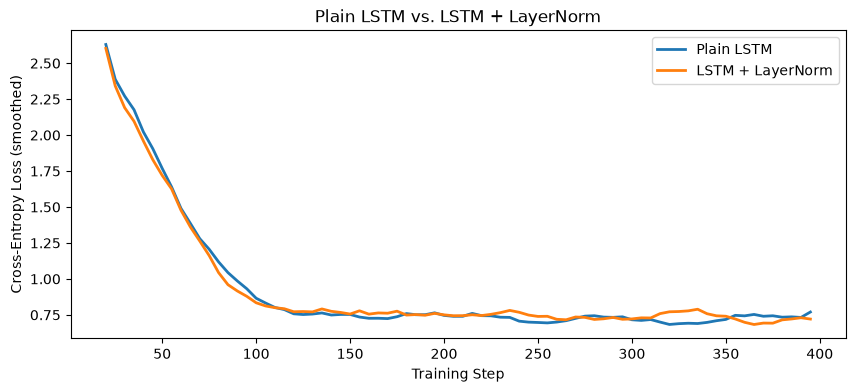

In [32]:
def smooth(lossi, window=5):
    if len(lossi) < window:
        return None
    return np.convolve(lossi, np.ones(window) / window, mode='valid')

window = 5
plt.figure(figsize=(10, 4))

s_plain = smooth(lossi_plain, window)
s_ln = smooth(lossi_ln, window)

if s_plain is not None:
    plt.plot(stepi_plain[window-1:], s_plain, label='Plain LSTM', linewidth=2)
if s_ln is not None:
    plt.plot(stepi_ln[window-1:], s_ln, label='LSTM + LayerNorm', linewidth=2)

# plt.plot(stepi_plain, lossi_plain, label='LSTM', linewidth=2)
# plt.plot(stepi_ln, lossi_ln, label='LSTM + LayerNorm', linewidth=2)

plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss (smoothed)')
plt.title('Plain LSTM vs. LSTM + LayerNorm')
plt.legend()
plt.show()

### 6.1 Experiment 1: Higher learning rate — does LayerNorm handle it better?

In [33]:
# Experiment 1: Higher learning rate — does LayerNorm handle it better?
high_lr = 0.25  # 25x the default learning rate
emb_size, hidden_size = 24, 128

model_plain_hlr = CharLSTM(vocab_size, emb_size, hidden_size, cell_class=LSTMCell, pad_idx=PAD_IDX)
model_ln_hlr    = CharLSTM(vocab_size, emb_size, hidden_size, cell_class=LSTMCell_LN, pad_idx=PAD_IDX)

print('Training plain LSTM...')
lossi_plain_hlr, stepi_plain_hlr = train_model(model_plain_hlr, words.copy(), lr=high_lr)

print('\nTraining LSTM + LayerNorm...')
lossi_ln_hlr, stepi_ln_hlr = train_model(model_ln_hlr, words.copy(), lr=high_lr)

Training plain LSTM...
Epoch  1/100 | Loss: 5.6856 | Time: 0.0s
Epoch 10/100 | Loss: 1.7490 | Time: 0.3s
Epoch 20/100 | Loss: 1.3822 | Time: 0.5s
Epoch 30/100 | Loss: 1.8821 | Time: 0.7s
Epoch 40/100 | Loss: 1.8465 | Time: 0.9s
Epoch 50/100 | Loss: 1.9204 | Time: 1.1s
Epoch 60/100 | Loss: 2.0121 | Time: 1.3s
Epoch 70/100 | Loss: 1.9136 | Time: 1.5s
Epoch 80/100 | Loss: 1.6511 | Time: 1.7s
Epoch 90/100 | Loss: 1.3635 | Time: 1.9s
Epoch 100/100 | Loss: 1.3258 | Time: 2.1s
Training complete in 2.1s (400 total steps)

Training LSTM + LayerNorm...
Epoch  1/100 | Loss: 5.3624 | Time: 0.0s
Epoch 10/100 | Loss: 1.9874 | Time: 0.5s
Epoch 20/100 | Loss: 1.2823 | Time: 0.9s
Epoch 30/100 | Loss: 0.9710 | Time: 1.4s
Epoch 40/100 | Loss: 0.8507 | Time: 1.8s
Epoch 50/100 | Loss: 0.8334 | Time: 2.3s
Epoch 60/100 | Loss: 0.8139 | Time: 2.7s
Epoch 70/100 | Loss: 0.7949 | Time: 3.1s
Epoch 80/100 | Loss: 0.7930 | Time: 3.5s
Epoch 90/100 | Loss: 0.7673 | Time: 3.9s
Epoch 100/100 | Loss: 0.7569 | Time: 4.3s

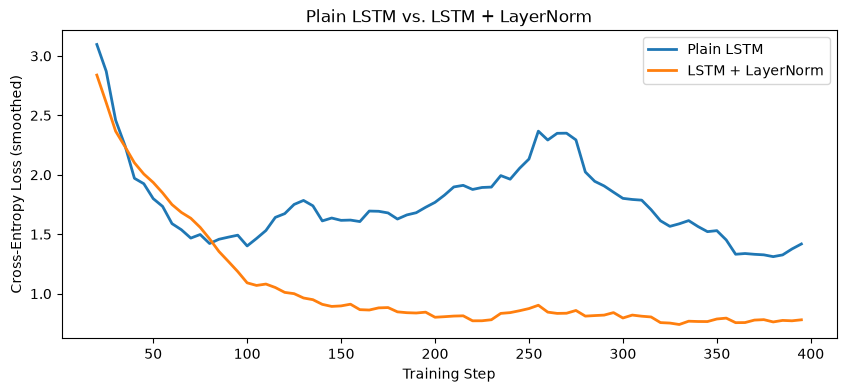

In [34]:
def smooth(lossi, window=5):
    if len(lossi) < window:
        return None
    return np.convolve(lossi, np.ones(window) / window, mode='valid')

window = 5
plt.figure(figsize=(10, 4))

s_plain_hlr = smooth(lossi_plain_hlr, window)
s_ln_hlr = smooth(lossi_ln_hlr, window)

if s_plain_hlr is not None:
    plt.plot(stepi_plain_hlr[window-1:], s_plain_hlr, label='Plain LSTM', linewidth=2)
if s_ln_hlr is not None:
    plt.plot(stepi_ln_hlr[window-1:], s_ln_hlr, label='LSTM + LayerNorm', linewidth=2)

plt.xlabel('Training Step')
plt.ylabel('Cross-Entropy Loss (smoothed)')
plt.title('Plain LSTM vs. LSTM + LayerNorm')
plt.legend()
plt.show()

## 7. Qualitative Comparison

In [35]:
@torch.no_grad()
def generate_names(model, n=5, temperature=1.0, max_len=20):
    model.eval()
    device = next(model.parameters()).device

    h = torch.zeros(n, model.lstm_cell.hidden_size, device=device)
    c = torch.zeros(n, model.lstm_cell.hidden_size, device=device)

    idx = torch.zeros(n, dtype=torch.long, device=device)
    finished = torch.zeros(n, dtype=torch.bool, device=device)
    generated = [[] for _ in range(n)]

    for _ in range(max_len):
        x = model.emb(idx)
        h, c = model.lstm_cell(x, (h, c))
        logits = model.fc(h) / temperature
        logits[:, PAD_IDX] = float('-inf')
        probs = F.softmax(logits, dim=-1)
        idx = torch.multinomial(probs, num_samples=1).squeeze(-1)

        finished |= (idx == 0)
        for b in range(n):
            if not finished[b]:
                generated[b].append(itos[idx[b].item()])

        if finished.all():
            break

    model.train()
    return [''.join(g) for g in generated]


print('Plain LSTM samples:')
print(generate_names(model_plain, n=10, temperature=0.8))

print('\nLSTM + LayerNorm samples:')
print(generate_names(model_ln, n=10, temperature=0.8))

Plain LSTM samples:
['liam', 'lena', 'sebastian', 'genesis', 'ava', 'layla', 'claire', 'asher', 'savannah', 'lily']

LSTM + LayerNorm samples:
['leah', 'mateo', 'nova', 'elizabeth', 'elara', 'genesis', 'jades', 'serenity', 'emma', 'alexander']


## 8. Design Decision: Should We Normalize $C_t$?

So far we've normalized only the **gate pre-activations**. Some papers (including the original LayerNorm paper by Ba et al., 2016) also normalize the **cell state $C_t$** before computing the hidden state:

$$h_t = o_t \odot \tanh(\text{LayerNorm}(C_t))$$

vs. the standard:

$$h_t = o_t \odot \tanh(C_t)$$

The tradeoff:
- **Normalizing $C_t$** stabilizes the hidden state output, preventing it from drifting to extreme magnitudes over long sequences.
- **Not normalizing $C_t$** preserves the magnitude information that the cell state was specifically designed to carry — one of the LSTM's key advantages over vanilla RNNs.

## 9. Summary

Here's what we built and learned:

**LayerNorm from scratch**: We implemented layer normalization as a standalone module — compute mean/variance over features, normalize, then scale and shift with learnable $\gamma$ and $\beta$. Verified our implementation matches PyTorch's `nn.LayerNorm` to within numerical precision.

**Why LayerNorm for RNNs**: Unlike BatchNorm (which normalizes across the batch), LayerNorm normalizes across features per example — making it a natural fit for sequential data with variable-length inputs and no dependence on batch statistics at inference time.

**Training stability**: Our side-by-side experiments showed that LayerNorm-LSTM converges at a comparable or better rate than vanilla LSTM at the same learning rate, and crucially, **handles higher learning rates without diverging** — directly demonstrating the stabilization effect.

**Design nuance**: Normalizing gate pre-activations is the standard and most impactful placement. Normalizing $C_t$ is an additional option that can help on longer sequences but risks losing the magnitude information the cell state was designed to preserve.

**Bridge to nanoGPT**: LayerNorm is not just an RNN technique — it's a core component of every Transformer block. The $\gamma$, $\beta$ learnable scale/shift pattern you now understand from scratch is exactly what nanoGPT uses inside its attention and MLP layers.

## 10. What's Next?

1. **GRU from Scratch**: The GRU (Gated Recurrent Unit) merges the cell state and hidden state into a single vector, using update and reset gates instead of the LSTM's forget/input/output gates. Implement a GRU cell from scratch, train it on the same dataset, and compare against `nn.GRU` — the strongest "compare and contrast" exercise so far.

2. **Attention Mechanism**: Move from "compress all history into a fixed-size hidden state" to "look back at specific previous positions directly." Implement query/key/value projections, compute attention weights, and apply them to LSTM outputs — the idea that displaced RNNs and underpins every Transformer.